# Chapter 4 Application

## Installing Packages

In [ ]:
!pip install uv && uv pip install ISLP
import ISLP
print(ISLP.__version__)

path = "/content/drive/Othercomputers/My MacBook Pro/Professional Development/Data Science/ISLP/ISLP/"

Using Python 3.12.13 environment at: /usr
Checked 1 package in 310ms
0.4.1


In [ ]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         poly,
                         summarize)
from ISLP import confusion_table
from ISLP.models import contrast

from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error

## 13. Weekly Data Set

### a) EDA

In [ ]:
Weekly = load_data('Weekly')
Weekly['Direction'] = Weekly['Direction'].map({'Down': 0, 'Up': 1})

Weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,0
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,0
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,1
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,1
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,1
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,1
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,1
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,1
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,1


In [ ]:
Weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


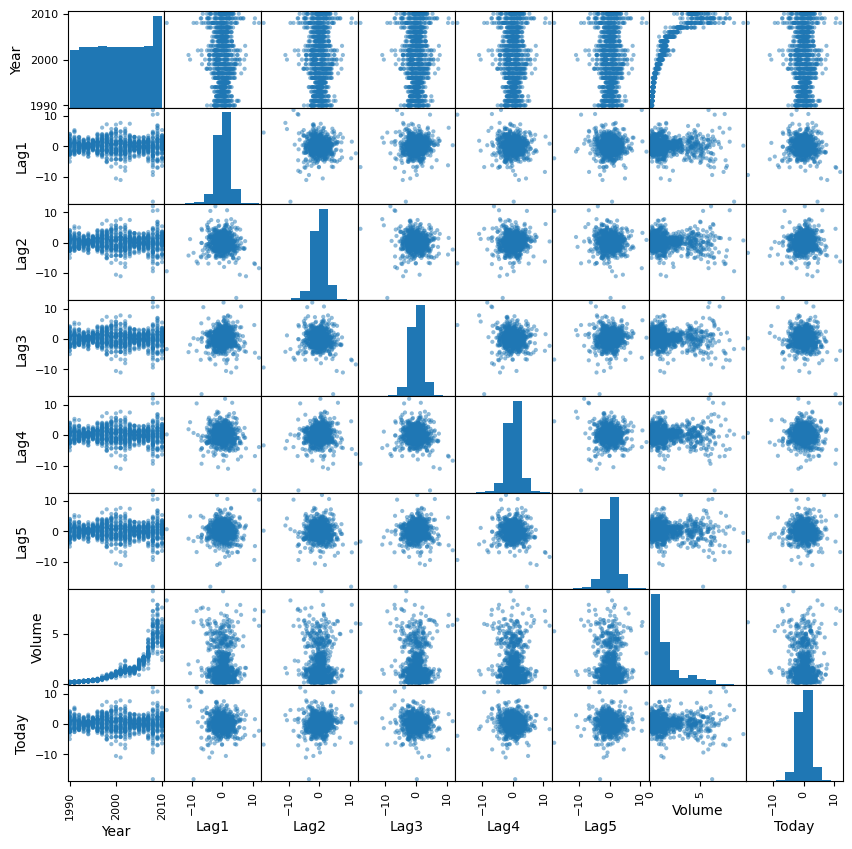

In [ ]:
pd.plotting.scatter_matrix(Weekly, figsize=(10,10));

<Axes: >

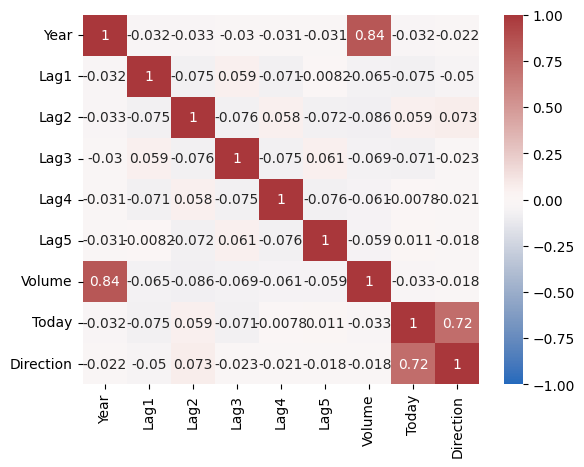

In [ ]:
corr_m = Weekly.corr()
sns.heatmap(corr_m, cmap='vlag', annot=True, vmin=-1, vmax=1)

- Lag1-Lag5 are not correlated with each other and have very weak association.
- Year and Volume are positively correlated.
- Lags x Year and Lags x Volume have no trend or correlation.
- No clear relationship between any of the variables and Today's return.

### b) Log Reg

In [ ]:
X = Weekly.drop(columns=['Today', 'Direction', 'Year'])
y = Weekly['Direction']
X, y

(       Lag1   Lag2   Lag3   Lag4   Lag5    Volume
 0     0.816  1.572 -3.936 -0.229 -3.484  0.154976
 1    -0.270  0.816  1.572 -3.936 -0.229  0.148574
 2    -2.576 -0.270  0.816  1.572 -3.936  0.159837
 3     3.514 -2.576 -0.270  0.816  1.572  0.161630
 4     0.712  3.514 -2.576 -0.270  0.816  0.153728
 ...     ...    ...    ...    ...    ...       ...
 1084 -0.861  0.043 -2.173  3.599  0.015  3.205160
 1085  2.969 -0.861  0.043 -2.173  3.599  4.242568
 1086  1.281  2.969 -0.861  0.043 -2.173  4.835082
 1087  0.283  1.281  2.969 -0.861  0.043  4.454044
 1088  1.034  0.283  1.281  2.969 -0.861  2.707105
 
 [1089 rows x 6 columns],
 0       0
 1       0
 2       1
 3       1
 4       1
        ..
 1084    1
 1085    1
 1086    1
 1087    1
 1088    1
 Name: Direction, Length: 1089, dtype: category
 Categories (2, int64): [0, 1])

In [ ]:
model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()
summarize(results)

,coef,std err,z,P>|z|
Lag1,-0.0327,0.026,-1.250,0.211
Lag2,0.0682,0.027,2.556,0.011
Lag3,-0.0081,0.026,-0.306,0.759
Lag4,-0.0194,0.026,-0.740,0.459
Lag5,-0.0069,0.026,-0.261,0.794
Volume,0.0569,0.027,2.125,0.034


- Only *Lag2* is statistically significant

### c) Evaluating Log Reg

In [ ]:
model_pred = results.predict()
model_pred[model_pred > 0.5] = 1
model_pred[model_pred <= 0.5] = 0

confusion_table(model_pred, y)

Truth,0,1
Predicted,,
0,172,178
1,312,427


In [ ]:
# Accuracy
(172+427)/(54+557+430+48)

0.5500459136822773

In [ ]:
# Null-rate
(178+427)/(54+557+430+48)

0.5555555555555556

- The Logistic Regression marked most of the predictions true.
- Resulting accuracy was slightly worse than the null-rate performance.
- The model closely mirrors the naive majority class selection model.

### d) Log Reg w/ Lag2 only

In [ ]:
X = Weekly.drop(columns="Direction")
y = Weekly["Direction"]

drop_cols = Weekly.columns.drop(['Lag2', 'Direction'])
train_mask = Weekly["Year"] <= 2008

X_train = X[train_mask].drop(columns=drop_cols)
X_test = X[~train_mask].drop(columns=drop_cols)

y_train = y[train_mask]
y_test = y[~train_mask]

X_train, y_train, X_test, y_test

(       Lag2
 0     1.572
 1     0.816
 2    -0.270
 3    -2.576
 4     3.514
 ..      ...
 980  -8.389
 981  12.026
 982  -2.251
 983   0.418
 984   0.926
 
 [985 rows x 1 columns],
 0      0
 1      0
 2      1
 3      1
 4      1
       ..
 980    0
 981    1
 982    1
 983    0
 984    1
 Name: Direction, Length: 985, dtype: category
 Categories (2, int64): [0, 1],
        Lag2
 985  -1.698
 986   6.760
 987  -4.448
 988  -4.518
 989  -2.137
 ...     ...
 1084  0.043
 1085 -0.861
 1086  2.969
 1087  1.281
 1088  0.283
 
 [104 rows x 1 columns],
 985     0
 986     0
 987     0
 988     0
 989     1
        ..
 1084    1
 1085    1
 1086    1
 1087    1
 1088    1
 Name: Direction, Length: 104, dtype: category
 Categories (2, int64): [0, 1])

In [ ]:
terms = MS(['Lag2'])
X_train = terms.fit_transform(X_train)
X_test = terms.transform(X_test)

model = sm.GLM(y_train, X_train, sm.families.Binomial())
results = model.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2033,0.064,3.162,0.002
Lag2,0.0581,0.029,2.024,0.043


In [ ]:
y_pred = results.predict(X_test)
y_pred[y_pred > 0.5] = 1
y_pred[y_pred <= 0.5] = 0
confusion_table(y_pred, y_test)

Truth,0,1
Predicted,,
0,9,5
1,34,56


In [ ]:
# Accuracy
(9+56)/(104)

0.625

In [ ]:
# Null-rate
(5+56)/(104)

0.5865384615384616

### e) LDA

In [ ]:
# skikitlearn handles intercepts itself
X_train = X[train_mask].drop(columns=drop_cols)
X_test = X[~train_mask].drop(columns=drop_cols)

# Define and fit the model
lda = LDA(store_covariance=True)
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis(store_covariance=True)

In [ ]:
y_pred = lda.predict(X_test)
confusion_table(y_pred, y_test)

Truth,0,1
Predicted,,
0,9,5
1,34,56


In [ ]:
# Accuracy
(9+56)/(9+56+5+34)

0.625

### f) QDA

In [ ]:
qda = QDA(store_covariance=True)
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis(store_covariance=True)

In [ ]:
y_pred = qda.predict(X_test)
confusion_table(y_pred, y_test)

Truth,0,1
Predicted,,
0,0,0
1,43,61


In [ ]:
# Accuracy
(61)/(9+56+5+34)

0.5865384615384616

### g) KNN (K=1)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
confusion_table(y_pred, y_test)

Truth,0,1
Predicted,,
0,22,32
1,21,29


In [ ]:
# Accuracy
(22+29)/(21+32+22+29)

0.49038461538461536

### h) Naive Bayes

In [ ]:
NB = GaussianNB()
NB.fit(X_train, y_train)
y_pred = NB.predict(X_test)
confusion_table(y_pred, y_test)

Truth,0,1
Predicted,,
0,0,0
1,43,61


In [ ]:
# Accuracy = Null-rate
(61)/(21+32+22+29)

0.5865384615384616

### i) Results

According to the accuracies, only Logistic Regression and LDA result in highest scores of 62.5%.

### h) Experiment

In [ ]:
# Split into training and testing sets
train_mask = Weekly['Year'] < 2009

X = Weekly.drop(columns=['Today', 'Direction', 'Year'])
y = Weekly['Direction']

X_train = X[train_mask]
X_test = X[~train_mask]

y_train = y[train_mask]
y_test = y[~train_mask]

# Apply normalization
scalar = StandardScaler().set_output(transform="pandas")
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [ ]:
# Specify the model
terms = ['Lag1', 'Lag2', ('Lag1', 'Lag2')] # Adding 'Volume' or other 'Lags' decreases accuracy...
design = MS(terms)

# log reg is part of sm which requires MS intercept
# lda, qda, nb, and knn are part of skikit which adds intercept automatically
X_train_i = design.fit_transform(X_train)
X_test_i = design.transform(X_test)

X_train_ni = X_train_i.drop(columns='intercept')
X_test_ni = X_test_i.drop(columns='intercept')

In [ ]:
# Logistic Regression w/ ~58% Accuracy
print('Logistic Regression:')
lg = sm.GLM(y_train, X_train_i, sm.families.Binomial())
lg_r = lg.fit()

y_pred = lg_r.predict(X_test_i)
y_pred[y_pred > 0.5] = 1
y_pred[y_pred <= 0.5] = 0

print('\nConfusion Matrix:')
print(confusion_table(y_pred, y_test))
print('\nAccuracy Score:', accuracy_score(y_test, y_pred))

summarize(lg_r)

Logistic Regression:

Confusion Matrix:
Truth       0   1
Predicted        
0           7   8
1          36  53

Accuracy Score: 0.5769230769230769


,coef,std err,z,P>|z|
intercept,0.2119,0.064,3.291,0.001
Lag1,-0.1163,0.070,-1.651,0.099
Lag2,0.1218,0.066,1.842,0.066
Lag1:Lag2,0.0099,0.038,0.257,0.797


In [ ]:
# For skikit-learn's classes
def fit_predict(model):
  results = model.fit(X_train_ni, y_train)
  y_pred = model.predict(X_test_ni)

  print('\nConfusion Matrix:')
  print(confusion_table(y_pred, y_test))
  print('\nAccuracy Score:', accuracy_score(y_test, y_pred))

In [ ]:
# LDA w/ ~58% Accuracy
print('LDA:')
fit_predict(LDA(store_covariance=True))

print('\n\nQDA:')
fit_predict(QDA(store_covariance=True))

print('\n\nNaive Bayes:')
fit_predict(GaussianNB())

LDA:

Confusion Matrix:
Truth       0   1
Predicted        
0           7   8
1          36  53

Accuracy Score: 0.5769230769230769


QDA:

Confusion Matrix:
Truth       0   1
Predicted        
0          23  36
1          20  25

Accuracy Score: 0.46153846153846156


Naive Bayes:

Confusion Matrix:
Truth       0   1
Predicted        
0          17  30
1          26  31

Accuracy Score: 0.46153846153846156


In [ ]:
# Best K = 55 w/ ~60% Accuracy
for k in [1, 3, 10, 20, 50, 55, 60, 70]:
  print('\nKNN (k={}):'.format(k))
  knn = KNeighborsClassifier(n_neighbors=k)
  fit_predict(knn)


KNN (k=1):

Confusion Matrix:
Truth       0   1
Predicted        
0          17  28
1          26  33

Accuracy Score: 0.4807692307692308

KNN (k=3):

Confusion Matrix:
Truth       0   1
Predicted        
0          26  33
1          17  28

Accuracy Score: 0.5192307692307693

KNN (k=10):

Confusion Matrix:
Truth       0   1
Predicted        
0          23  36
1          20  25

Accuracy Score: 0.46153846153846156

KNN (k=20):

Confusion Matrix:
Truth       0   1
Predicted        
0          18  25
1          25  36

Accuracy Score: 0.5192307692307693

KNN (k=50):

Confusion Matrix:
Truth       0   1
Predicted        
0          18  22
1          25  39

Accuracy Score: 0.5480769230769231

KNN (k=55):

Confusion Matrix:
Truth       0   1
Predicted        
0          17  16
1          26  45

Accuracy Score: 0.5961538461538461

KNN (k=60):

Confusion Matrix:
Truth       0   1
Predicted        
0          19  21
1          24  40

Accuracy Score: 0.5673076923076923

KNN (k=70):

Confusi

## 14. Auto Data Set

### a) Load Data

In [ ]:
Auto = load_data("Auto")
mpg01 = Auto['mpg'] > Auto['mpg'].median()
mpg01 = mpg01.astype(int)
Auto['mpg01'] = mpg01
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,0
ford torino,17.0,8,302.0,140,3449,10.5,70,1,0
...,...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2,1
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1,1


### b) EDA

In [ ]:
Auto = Auto.drop(columns=['mpg'])

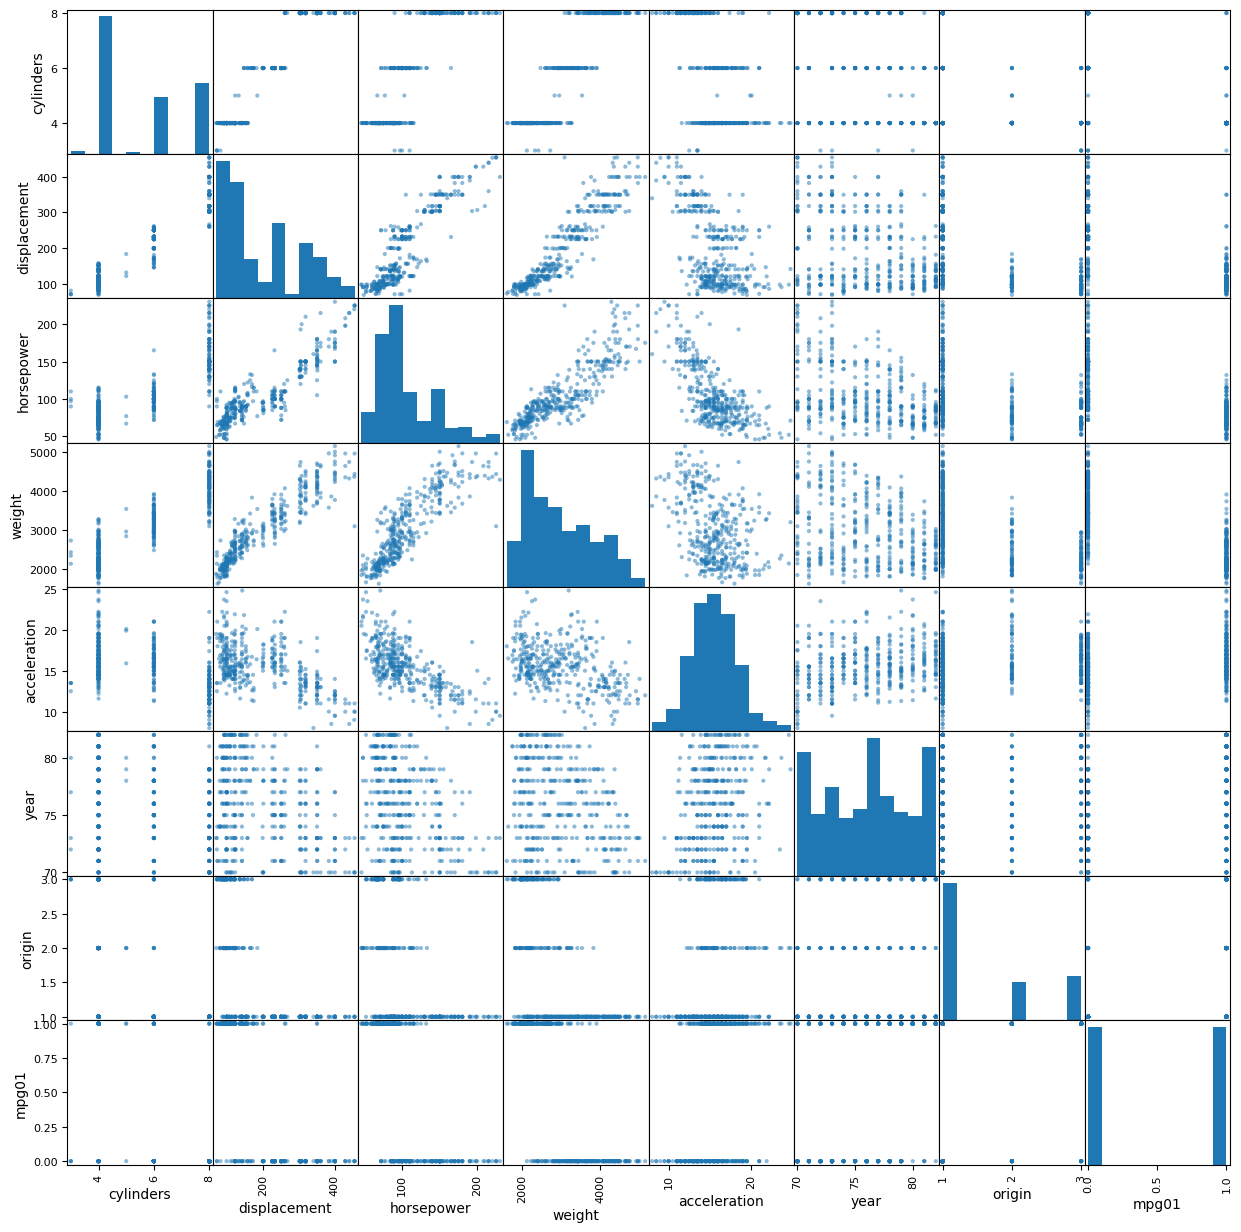

In [ ]:
pd.plotting.scatter_matrix(Auto, figsize=(15,15));

<Axes: >

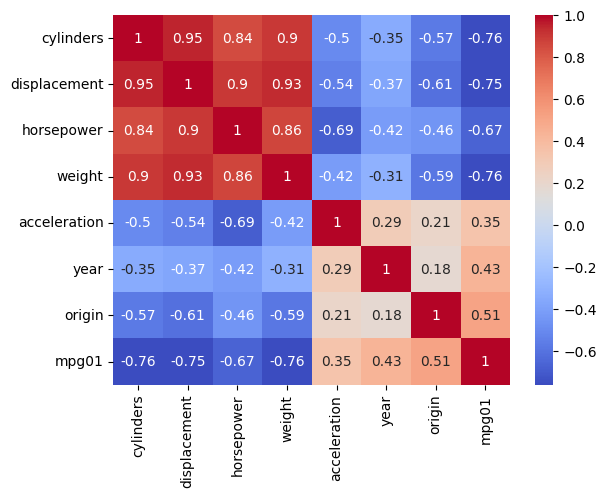

In [ ]:
sns.heatmap(Auto.corr(), annot=Auto.corr(), cmap='coolwarm')

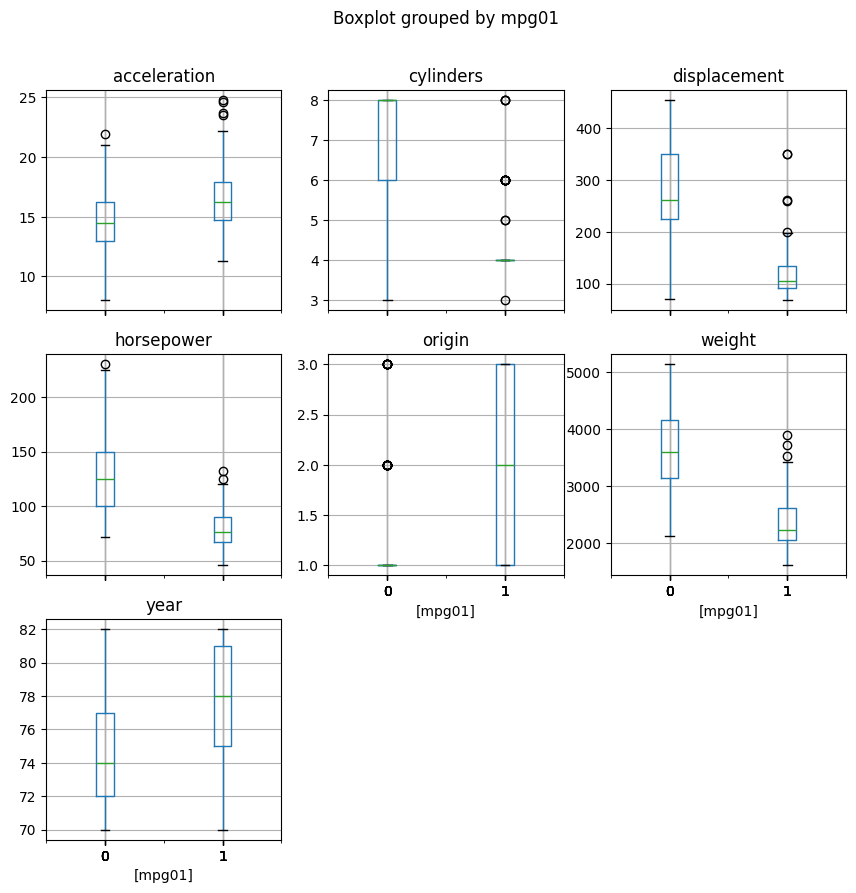

In [ ]:
Auto.boxplot(by='mpg01', sharey=False, figsize=(10,10));

Displacement, horspower, weight, and cylinders are the strongest predictors
Year, origin, and acceleration might be less significant, but still provide meaningful insight

### c) Train-Test Split

In [ ]:
# Keeping 'displacement', 'horsepower', 'weight', and 'cylinders'
to_drop = Auto.columns.drop(['displacement', 'horsepower', 'weight', 'cylinders'])
X_train, X_test, y_train, y_test = train_test_split(Auto.drop(columns=to_drop),
                                                    Auto['mpg01'],
                                                    train_size=0.8,
                                                    random_state=1)

X_train, X_test, y_train, y_test

(                                  cylinders  displacement  horsepower  weight
 name                                                                         
 plymouth reliant                          4         135.0          84    2490
 dodge aspen                               6         225.0         110    3620
 audi fox                                  4          98.0          83    2219
 datsun 310                                4          86.0          65    2019
 volkswagen jetta                          4         105.0          74    2190
 ...                                     ...           ...         ...     ...
 toyota corolla                            4          97.0          75    2155
 amc concord                               6         232.0          90    3210
 chevrolet chevelle concours (sw)          8         307.0         130    4098
 chevrolet chevette                        4          98.0          63    2051
 chevrolet impala                          8        

### d-h) Modeling

In [ ]:
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def fit_predict(model):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print('Test Error:', mean_squared_error(y_test, y_pred))

### d) LDA

In [ ]:
fit_predict(LDA(store_covariance=True))

Test Error: 0.06329113924050633


### e) QDA

In [ ]:
fit_predict(QDA(store_covariance=True))

Test Error: 0.0379746835443038


### f) Logistic Regression

In [ ]:
# sm requires ModelSpec intercept
design = MS(X_train.columns)
X_train_i = design.fit_transform(X_train)
X_test_i = design.transform(X_test)

# Fit the model
lg = sm.GLM(y_train, X_train_i, sm.families.Binomial())
lg_r = lg.fit()

# Predict
y_pred = lg_r.predict(X_test_i)
y_pred[y_pred > 0.5] = 1
y_pred[y_pred <= 0.5] = 0

print('Test Error:', mean_squared_error(y_test, y_pred))

Test Error: 0.05063291139240506


### g) Naive Bayes

In [ ]:
fit_predict(GaussianNB())

Test Error: 0.05063291139240506


### h) KNN

In [ ]:
# k = 10 is the best
for k in [1, 5, 7, 8, 9, 10, 11, 15, 20, 100]:
  print('\nFor k =', k)
  fit_predict(KNeighborsClassifier(n_neighbors=k))


For k = 1
Test Error: 0.0759493670886076

For k = 5
Test Error: 0.0759493670886076

For k = 7
Test Error: 0.06329113924050633

For k = 8
Test Error: 0.06329113924050633

For k = 9
Test Error: 0.0379746835443038

For k = 10
Test Error: 0.0379746835443038

For k = 11
Test Error: 0.05063291139240506

For k = 15
Test Error: 0.05063291139240506

For k = 20
Test Error: 0.05063291139240506

For k = 100
Test Error: 0.05063291139240506


## 15. Power Functions

### a) 2^3

In [ ]:
def Power():
  print(2**3)

Power()

8


### b) Print x^a

In [ ]:
def Power2(x, a):
  print(x**a)

Power2(3, 8)

6561


### c) 10^3, 8^17, 131^3

In [ ]:
Power2(10,3)
Power2(8,17)
Power2(131,3)

1000
2251799813685248
2248091


### d) Return x^a

In [ ]:
def Power3(x, a):
  result = x**a
  return result

print(Power3(2,3))

8


### e) Plotting x^2

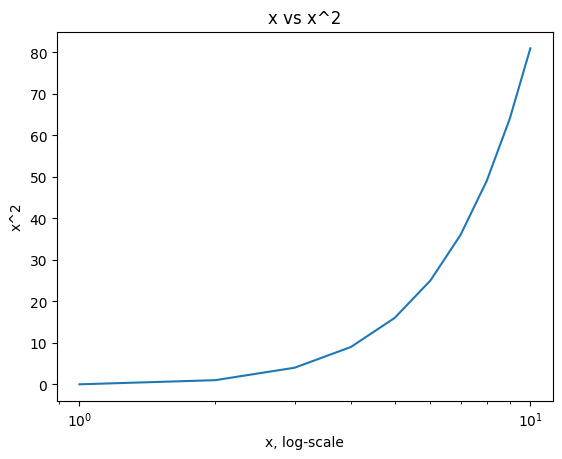

In [ ]:
# Basic
# y = np.zeros(10)
# for n in range(10):
#   y[n] = Power3(n, 2)

# More elegant
y = np.array([Power3(n, 2) for n in range(10)])

# Graphing
plt.plot(np.arange(1,11), y)

# plt.yscale('log')
plt.xscale('log')

plt.title('x vs x^2')
plt.xlabel('x, log-scale')
plt.ylabel('x^2')

plt.show()

### f) Plot Power

In [ ]:
def PlotPower(x, a):
  y = np.array([Power3(n, a) for n in x])

  plt.plot(x, y)
  plt.title('x vs x^a')
  plt.xlabel('x')
  plt.ylabel('x^a')

  plt.show()

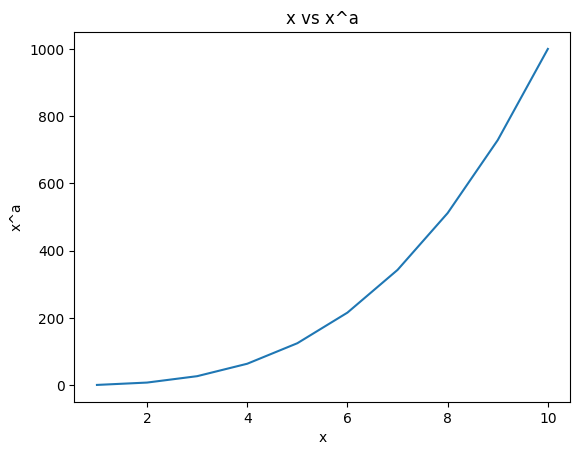

In [ ]:
PlotPower(np.arange(1, 11), 3)

## 16. Boston Dataset

### Load Data

In [326]:
Boston = load_data('Boston')
crim01 = Boston['crim'] > Boston['crim'].median()
crim01 = crim01.astype(int)
Boston['crim01'] = crim01
Boston = Boston.drop(columns=['crim'])
Boston

,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,crim01
0,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,0
3,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,0
4,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4,0
502,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6,0
503,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9,0
504,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0,0


### EDA

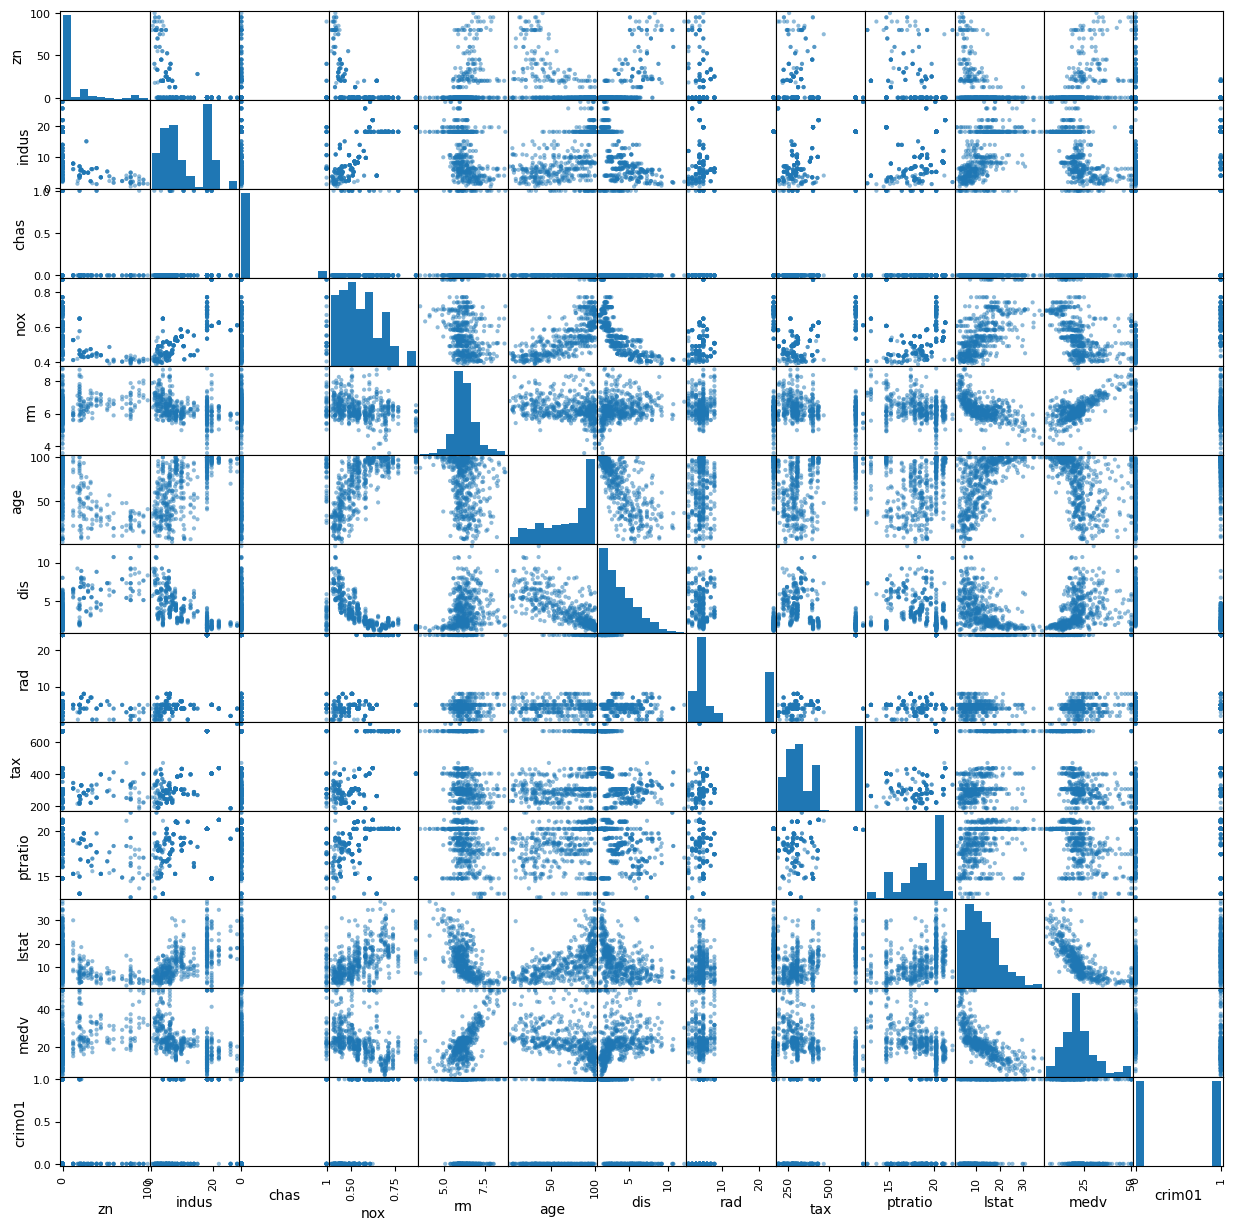

In [327]:
pd.plotting.scatter_matrix(Boston, figsize=(15,15));

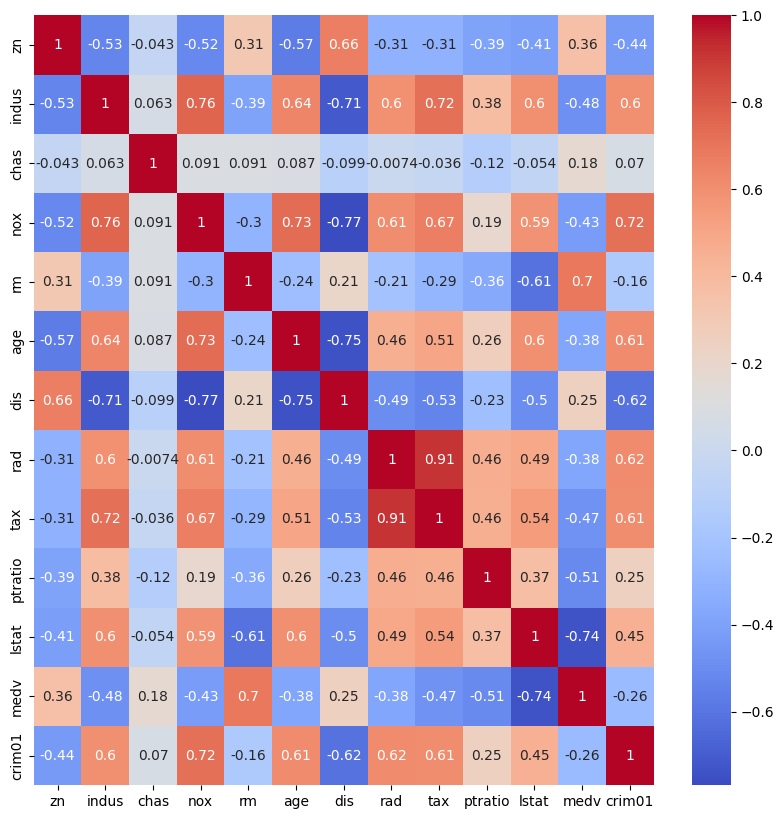

In [328]:
plt.figure(figsize=(10,10))
sns.heatmap(Boston.corr(), annot=Boston.corr(), cmap='coolwarm')
plt.show()

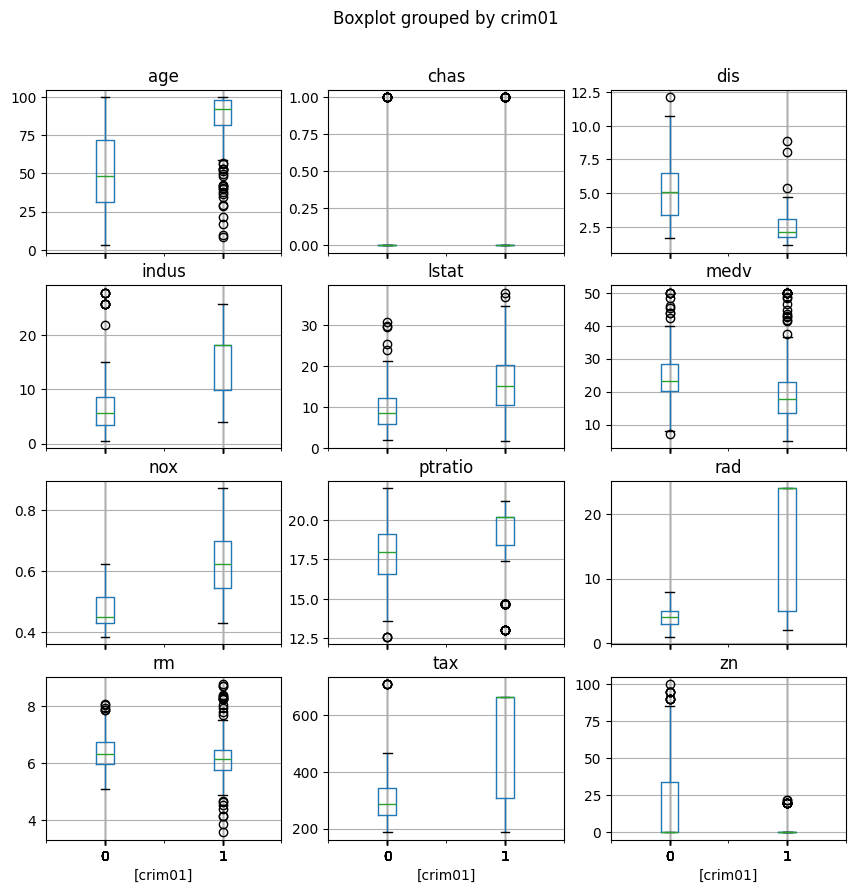

In [329]:
Boston.boxplot(by='crim01', sharey=False, figsize=(10,10));

### Modeling

In [330]:
# Run models
def run_models(data, terms, target):

  data = preprocess_data(data, terms, target)

  # Logistic Regression
  print('LogisticRegression: ', end="")
  lg = sm.GLM(data[2], data[0], sm.families.Binomial())
  y_pred = lg.fit().predict(data[1])
  y_pred[y_pred > 0.5] = 1
  y_pred[y_pred <= 0.5] = 0
  print('MSE: {:.2f}, Accuracy: {:.2f}'.format(mean_squared_error(data[3], y_pred),
                                               accuracy_score(data[3], y_pred)), end="")

  # LDA, QDA, Naive Bayes Batch
  data[0] = data[0].drop(columns='intercept')
  data[1] = data[1].drop(columns='intercept')

  for model in [LDA(store_covariance=True), QDA(store_covariance=True), GaussianNB()]:
    print()
    print(model.__class__.__name__, end=": ")
    fit_predict(model, data)

  # KNN
  print('\n\n\tKNeighborsClassifier:', end="")
  for k in [1, 5, 10, 15, 20, 35, 50, 75, 100]:
    print('\nFor k =', k, end=": ")
    fit_predict(KNeighborsClassifier(n_neighbors=k), data)



# Preprocess the data
def preprocess_data(data, terms, target):

  # Train-Test Split
  X = Boston.drop(columns=[target])
  y = Boston[target]
  X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      random_state=1,
                                                      train_size=0.8)

  # Data Normalization
  scaler = StandardScaler().set_output(transform="pandas")
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  # Terms
  design = MS(terms)
  X_train = design.fit_transform(X_train)
  X_test = design.transform(X_test)

  return [X_train, X_test, y_train, y_test]



# Run and evaluate the model
def fit_predict(model, data):
  model.fit(data[0], data[2])
  y_pred = model.predict(data[1])
  print('MSE: {:.2f}, Accuracy: {:.2f}'.format(mean_squared_error(data[3], y_pred),
                                               accuracy_score(data[3], y_pred)), end="")

In [331]:
# Different Combinations
def run_Boston(terms):
  print("Terms:", terms)
  run_models(Boston, terms, 'crim01')
  print("\n\n\n")

### Evaluation

In [332]:
run_Boston(['rad', 'tax', 'lstat'])
run_Boston([poly('rad', degree=2), poly('tax', degree=2), poly('lstat', degree=2)])
run_Boston([poly('rad', degree=3), poly('tax', degree=3), poly('lstat', degree=3)])

Terms: ['rad', 'tax', 'lstat']
LogisticRegression: MSE: 0.27, Accuracy: 0.73
LinearDiscriminantAnalysis: MSE: 0.28, Accuracy: 0.72
QuadraticDiscriminantAnalysis: MSE: 0.27, Accuracy: 0.73
GaussianNB: MSE: 0.28, Accuracy: 0.72

	KNeighborsClassifier:
For k = 1: MSE: 0.17, Accuracy: 0.83
For k = 5: MSE: 0.23, Accuracy: 0.77
For k = 10: MSE: 0.20, Accuracy: 0.80
For k = 15: MSE: 0.24, Accuracy: 0.76
For k = 20: MSE: 0.25, Accuracy: 0.75
For k = 35: MSE: 0.27, Accuracy: 0.73
For k = 50: MSE: 0.25, Accuracy: 0.75
For k = 75: MSE: 0.27, Accuracy: 0.73
For k = 100: MSE: 0.30, Accuracy: 0.70



Terms: [Feature(variables=('rad',), name='poly(rad, degree=2)', encoder=Poly(degree=2), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('tax',), name='poly(tax, degree=2)', encoder=Poly(degree=2), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('lstat',), name='poly(lstat, degree=2)', encoder=Poly(degree=2), use_tran

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [333]:
run_Boston(['nox', 'age', 'dis', 'rad', 'tax', 'lstat'])
run_Boston([poly('nox', degree=2), poly('age', degree=2), poly('dis', degree=2), poly('rad', degree=2), poly('tax', degree=2), poly('lstat', degree=2)])
run_Boston([poly('nox', degree=3), poly('age', degree=3), poly('dis', degree=3), poly('rad', degree=3), poly('tax', degree=3), poly('lstat', degree=3)])

Terms: ['nox', 'age', 'dis', 'rad', 'tax', 'lstat']
LogisticRegression: MSE: 0.12, Accuracy: 0.88
LinearDiscriminantAnalysis: MSE: 0.18, Accuracy: 0.82
QuadraticDiscriminantAnalysis: MSE: 0.14, Accuracy: 0.86
GaussianNB: MSE: 0.20, Accuracy: 0.80

	KNeighborsClassifier:
For k = 1: MSE: 0.10, Accuracy: 0.90
For k = 5: MSE: 0.12, Accuracy: 0.88
For k = 10: MSE: 0.13, Accuracy: 0.87
For k = 15: MSE: 0.13, Accuracy: 0.87
For k = 20: MSE: 0.17, Accuracy: 0.83
For k = 35: MSE: 0.15, Accuracy: 0.85
For k = 50: MSE: 0.19, Accuracy: 0.81
For k = 75: MSE: 0.20, Accuracy: 0.80
For k = 100: MSE: 0.21, Accuracy: 0.79



Terms: [Feature(variables=('nox',), name='poly(nox, degree=2)', encoder=Poly(degree=2), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('age',), name='poly(age, degree=2)', encoder=Poly(degree=2), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('dis',), name='poly(dis, degree=2)', encoder=Poly(de

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


MSE: 0.17, Accuracy: 0.83
For k = 75: MSE: 0.18, Accuracy: 0.82
For k = 100: MSE: 0.21, Accuracy: 0.79



Terms: [Feature(variables=('nox',), name='poly(nox, degree=3)', encoder=Poly(degree=3), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('age',), name='poly(age, degree=3)', encoder=Poly(degree=3), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('dis',), name='poly(dis, degree=3)', encoder=Poly(degree=3), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('rad',), name='poly(rad, degree=3)', encoder=Poly(degree=3), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('tax',), name='poly(tax, degree=3)', encoder=Poly(degree=3), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('lstat',), name='poly(lstat, degree=3)', encoder=Poly(degree=3), use_transform=True, pure_columns=Fals

In [334]:
run_Boston(['indus', 'nox', 'age', 'dis', 'rad', 'tax', 'lstat'])
run_Boston([poly('indus', degree=2), poly('nox', degree=2), poly('age', degree=2), poly('dis', degree=2), poly('rad', degree=2), poly('tax', degree=2), poly('lstat', degree=2)])
run_Boston([poly('indus', degree=3), poly('nox', degree=3), poly('age', degree=3), poly('dis', degree=3), poly('rad', degree=3), poly('tax', degree=3), poly('lstat', degree=3)])

Terms: ['indus', 'nox', 'age', 'dis', 'rad', 'tax', 'lstat']
LogisticRegression: MSE: 0.11, Accuracy: 0.89
LinearDiscriminantAnalysis: MSE: 0.19, Accuracy: 0.81
QuadraticDiscriminantAnalysis: MSE: 0.12, Accuracy: 0.88
GaussianNB: MSE: 0.21, Accuracy: 0.79

	KNeighborsClassifier:
For k = 1: MSE: 0.06, Accuracy: 0.94
For k = 5: MSE: 0.10, Accuracy: 0.90
For k = 10: MSE: 0.12, Accuracy: 0.88
For k = 15: MSE: 0.14, Accuracy: 0.86
For k = 20: MSE: 0.16, Accuracy: 0.84
For k = 35: MSE: 0.16, Accuracy: 0.84
For k = 50: MSE: 0.22, Accuracy: 0.78
For k = 75: MSE: 0.25, Accuracy: 0.75
For k = 100: MSE: 0.24, Accuracy: 0.76



Terms: [Feature(variables=('indus',), name='poly(indus, degree=2)', encoder=Poly(degree=2), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('nox',), name='poly(nox, degree=2)', encoder=Poly(degree=2), use_transform=True, pure_columns=False, override_encoder_colnames=True), Feature(variables=('age',), name='poly(age, degree=2)', en

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


MSE: 0.04, Accuracy: 0.96
For k = 5: MSE: 0.09, Accuracy: 0.91
For k = 10: MSE: 0.09, Accuracy: 0.91
For k = 15: MSE: 0.09, Accuracy: 0.91
For k = 20: MSE: 0.09, Accuracy: 0.91
For k = 35: MSE: 0.14, Accuracy: 0.86
For k = 50: MSE: 0.20, Accuracy: 0.80
For k = 75: MSE: 0.21, Accuracy: 0.79
For k = 100: MSE: 0.21, Accuracy: 0.79





Assigning the terms that correlate with 'crim01' the most ('indus', 'nox', 'age', 'dis', 'rad', 'tax', 'lstat') has achieved already high results for Logistic Regression and KNN as well as others. Furthermore pushing the model by exercising non-linear associations of variables by fitting polynomial relationships (degree=3 specifically) allowed to increase accuracy measurements even more across all models. Throughout the experiment, Logistic Regression and KNN outperformed all other models. However, due to the covariance warnings and high accuracy, overfitting might be suspected and further evaluation might be needed. That said, even a simpler model might still yield more interpretable and grounding results than relying on the polynomials which has a little higher accuracy.


Best results achieved on the following terms, each fit with a 3rd degree polynomial: 'indus', 'nox', 'age', 'dis', 'rad', 'tax', 'lstat'.
- KNN: For k=1: MSE: 0.04, Accuracy: 0.96
- LR: MSE: 0.05, Accuracy: 0.95
- QDA: MSE: 0.08, Accuracy: 0.92
- LDA: MSE: 0.09, Accuracy: 0.91
- NB: MSE: 0.18, Accuracy: 0.82